### 0️. Importar Librerias

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

In [3]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (train_test_split,GridSearchCV)

from sklearn.preprocessing import (StandardScaler)

from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score,
    accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,
    classification_report)

from sklearn.linear_model import (LinearRegression,LogisticRegression,Ridge,Lasso,ElasticNet)

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Para que se muestren todas las columnas al inspeccionar los DataFrames
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 2000)
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)

In [4]:
from framework import sp_carga_exploracion as sc
from framework import sp_limpieza_transformacion as sl
from framework import sp_eda as se
from framework import sp_abtest as sb
from framework import sp_modelado as sm

### 1️. Cargar archivos csv Clasificación

#### cargar_csv X_clf

In [8]:
ruta = '../data/processed/X_clf.csv'
X_clf = sm.cargar_csv(ruta)

CSV CARGADO
Archivo: ../data/processed/X_clf.csv
Filas:   1000
Columnas: 18


In [9]:
type(X_clf)

pandas.DataFrame

#### cargar_csv y_clf

In [10]:
ruta = '../data/processed/y_clf.csv'
y_clf = sm.cargar_csv(ruta,squeeze=True)

CSV CARGADO
Archivo: ../data/processed/y_clf.csv
Filas:   1000
Columnas: 1 (Series)


In [11]:
type(y_clf)

pandas.Series

### 6. División Train/Test

train_test()

In [12]:
X_train_clf, X_test_clf, y_train_clf, y_test_clf = (
    sm.train_test(X_clf, y_clf))

In [13]:
print(X_train_clf.shape)
print(X_test_clf.shape)

print(y_train_clf.shape)
print(y_test_clf.shape)

(800, 18)
(200, 18)
(800,)
(200,)


### 7. Estandarización

In [14]:
X_train_clf.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
horas_estudio_semanal,800.0,10.05,4.90,1.0,6.55,9.96,13.36,25.0
nota_anterior,800.0,70.04,14.86,30.0,59.55,70.17,80.64,100.0
tasa_asistencia,800.0,73.99,18.16,20.0,61.45,75.05,88.18,100.0
horas_sueno,800.0,7.01,1.32,4.0,6.15,7.01,7.80,10.0
edad,800.0,23.52,3.46,18.0,21.00,24.00,26.00,29.0
tiene_tutor_ml,800.0,0.40,0.49,0.0,0.00,0.00,1.00,1.0
nivel_dificultad_dificil,800.0,0.18,0.38,0.0,0.00,0.00,0.00,1.0
nivel_dificultad_facil,800.0,0.31,0.46,0.0,0.00,0.00,1.00,1.0
nivel_dificultad_medio,800.0,0.51,0.50,0.0,0.00,1.00,1.00,1.0
horario_estudio_preferido_desconocido,800.0,0.10,0.30,0.0,0.00,0.00,0.00,1.0


#### estandarizar()

Descartamos:
Binarias, One Hot y tv

In [16]:
# columnas_continuas
columnas_escalar = ['horas_estudio_semanal','nota_anterior','tasa_asistencia','horas_sueno','edad']

In [17]:
X_train_clf, X_test_clf, scaler_clf = sm.estandarizar(
X_train_clf,
X_test_clf,
columnas=columnas_escalar
)

In [18]:
X_train_clf[
    columnas_escalar
].describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
horas_estudio_semanal,800.0,0.0,1.0,-1.85,-0.72,-0.02,0.67,3.05
nota_anterior,800.0,0.0,1.0,-2.70,-0.71,0.01,0.71,2.02
tasa_asistencia,800.0,-0.0,1.0,-2.98,-0.69,0.06,0.78,1.43
horas_sueno,800.0,-0.0,1.0,-2.28,-0.65,0.00,0.60,2.27
edad,800.0,-0.0,1.0,-1.60,-0.73,0.14,0.72,1.59


✅ Entrenamiento usando únicamente Train.

✅ Test transformado con el scaler de Train.

✅ Sin fuga de información.

✅ Variables continuas estandarizadas.

✅ Binarias y One Hot intactas.

Se aplica StandardScaler sobre las variables continuas:
 - horas_estudio_semanal - nota_anterior - tasa_asistencia - horas_sueno - edad 
 
 Las variables binarias y las obtenidas mediante One Hot Encoding se mantienen en su escala original (0/1). La media de las variables escaladas se aproxima a 0 y la desviación estándar a 1.

### 8. Entrenamiento Incial

#### entrenar_evaluar_clasificacion()

In [22]:
modelo = LogisticRegression(
    max_iter=1000
)

modelo, metricas, y_pred = (
    sm.entrenar_evaluar_clasificacion(
        modelo,
        X_train_clf,
        X_test_clf,
        y_train_clf,
        y_test_clf
    )
)
metricas


Matriz de confusión:
[[  2  13]
 [  3 182]]

Classification Report:
              precision    recall  f1-score   support

           0       0.40      0.13      0.20        15
           1       0.93      0.98      0.96       185

    accuracy                           0.92       200
   macro avg       0.67      0.56      0.58       200
weighted avg       0.89      0.92      0.90       200



{'Accuracy': 0.92,
 'Precision': 0.8933333333333333,
 'Recall': 0.92,
 'F1': 0.9010526315789474}

[[  2  13]<br>
 [  3 182]]

Classification Report:
              precision    recall  f1-score   support

           0       0.40      0.13      0.20        15
           1       0.93      0.98      0.96       185



Suspensos reales: 15<br>
Detectados correctamente: 2

Aprobados reales: 185<br>
Detectados correctamente: 182

### 9. Métricas

#### metricas_clasificacion()

In [23]:
sm.metricas_clasificacion(
    y_test_clf,
    y_pred
)

{'Accuracy': 0.92,
 'Precision': 0.8933333333333333,
 'Recall': 0.92,
 'F1': 0.9010526315789474}

Interpretación

El modelo consigue una precisión global del 92%.<br>
La predicción de estudiantes aprobados es muy buena (Recall = 0.98).<br>
Sin embargo, el modelo tiene dificultades para detectar los suspensos.<br>
De los 15 suspensos reales, solo identifica correctamente 2.<br>
El conjunto de datos parece estar desbalanceado, con muchos más aprobados que suspensos.<br>

Conclusión

El modelo ofrece un rendimiento global elevado, pero el Accuracy puede resultar engañoso debido al desequilibrio entre clases.<br>

Antes de considerar el modelo como definitivo, conviene analizar la distribución de la variable objetivo y comparar el comportamiento con otros algoritmos como:<br>

Decision Tree<br>
Random Forest

In [24]:
y_clf.value_counts()

aprobado_ml
1    898
0    102
Name: count, dtype: int64

In [25]:
y_clf.value_counts(normalize=True)*100

aprobado_ml
1    89.8
0    10.2
Name: proportion, dtype: float64

#### Conclusiones del modelo base: Logistic Regression


 Distribución de clases

| Clase | Registros |
|---------|---------:|
| Aprueba (1) | 898 |
| Suspende (0) | 102 |

El conjunto de datos presenta un importante desequilibrio entre clases.

 Resultados

| Métrica | Valor |
|----------|--------:|
| Accuracy | 0.92 |
| Precision | 0.893 |
| Recall | 0.920 |
| F1 | 0.901 |

Interpretación

El modelo obtiene una precisión global elevada (92%).

Sin embargo, el conjunto de datos se encuentra muy desbalanceado, ya que casi el 90% de los estudiantes pertenecen a la clase "Aprueba".

El modelo identifica correctamente la mayoría de los aprobados, pero tiene dificultades para detectar los suspensos.

Conclusión

Los resultados son prometedores como modelo base, aunque será necesario comparar su rendimiento con algoritmos más flexibles como:

- Decision Tree
- Random Forest

para comprobar si mejoran la detección de la clase minoritaria.

### 10. Validacion

#### comparar_train_test()

In [26]:
sm.comparar_train_test(
    modelo,
    X_train_clf,
    X_test_clf,
    y_train_clf,
    y_test_clf,
    tipo='clasificacion'
)

Accuracy Train: 0.8938
Accuracy Test : 0.9200


Validación del modelo

Se compara el rendimiento de la Regresión Logística sobre los conjuntos de entrenamiento y prueba.

| Métrica | Valor |
|----------|--------:|
| Accuracy Train | 0.894 |
| Accuracy Test | 0.920 |

Interpretación

- No se observan señales de sobreajuste.
- El rendimiento en test es incluso ligeramente superior al obtenido en entrenamiento.
- La diferencia entre ambos conjuntos es reducida y compatible con la variabilidad normal del muestreo.
- El modelo parece generalizar correctamente sobre datos no vistos.

Conclusión

La Regresión Logística proporciona una línea base sólida para el problema de clasificación y muestra una buena capacidad de generalización.

### 11. Comparación de modelos

#### comparar_modelos()

In [27]:
sm.comparar_modelos(
    X_train_clf,
    X_test_clf,
    y_train_clf,
    y_test_clf,
    tipo='clasificacion'
)

,Accuracy_train,Accuracy_test,F1_test
Logistic,0.8938,0.92,0.9011
Tree,1.0000,0.88,0.8890
Forest,1.0000,0.92,0.9011


Comparación de modelos

Se comparan distintos algoritmos de clasificación utilizando el mismo conjunto de entrenamiento y prueba.

| Modelo | Accuracy Train | Accuracy Test | F1 Test |
|----------|--------:|--------:|--------:|
| Logistic Regression | 0.894 | 0.920 | 0.901 |
| Decision Tree | 1.000 | 0.880 | 0.889 |
| Random Forest | 1.000 | 0.920 | 0.901 |

Interpretación

- Decision Tree presenta un claro sobreajuste (Accuracy Train = 100% y Accuracy Test = 88%).
- Logistic Regression mantiene un comportamiento estable entre entrenamiento y prueba.
- Random Forest alcanza el mismo Accuracy y F1 que Logistic Regression, aunque muestra una capacidad de ajuste mucho mayor sobre el conjunto de entrenamiento.
- Logistic Regression es el modelo más simple y estable de los evaluados.

Conclusión

No se observan mejoras relevantes al utilizar Random Forest frente a Logistic Regression.

Dado que ambos modelos obtienen resultados prácticamente idénticos en test, Logistic Regression se mantiene como un excelente candidato por:

- Menor complejidad.
- Mayor interpretabilidad.
- Menor riesgo de sobreajuste.
- Menor coste computacional.

Decision Tree queda descartado por sobreajuste.

### 12. Optimización

#### grid_search()

In [28]:
modelo = DecisionTreeClassifier(
    random_state=42
)

param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10]
}

mejor_modelo = sm.grid_search(
    modelo,
    param_grid,
    X_train_clf,
    y_train_clf,
    scoring='f1'
)


Mejores parámetros:
{'max_depth': 3, 'min_samples_split': 2}


In [29]:
modelo_tree = mejor_modelo

modelo_tree, metricas, y_pred = (
    sm.entrenar_evaluar_clasificacion(
        modelo_tree,
        X_train_clf,
        X_test_clf,
        y_train_clf,
        y_test_clf
    )
)

metricas


Matriz de confusión:
[[  4  11]
 [  7 178]]

Classification Report:
              precision    recall  f1-score   support

           0       0.36      0.27      0.31        15
           1       0.94      0.96      0.95       185

    accuracy                           0.91       200
   macro avg       0.65      0.61      0.63       200
weighted avg       0.90      0.91      0.90       200



{'Accuracy': 0.91,
 'Precision': 0.8984367484367485,
 'Recall': 0.91,
 'F1': 0.9035582064993829}

In [30]:
sm.comparar_train_test(
    modelo_tree,
    X_train_clf,
    X_test_clf,
    y_train_clf,
    y_test_clf,
    tipo='clasificacion'
)

Accuracy Train: 0.9087
Accuracy Test : 0.9100


Conclusiones de la optimización

El árbol de decisión inicial presentaba un claro sobreajuste:

- Accuracy Train = 100%
- Accuracy Test = 88%

Tras optimizar los hiperparámetros mediante Grid Search se obtiene:

- max_depth = 3
- min_samples_split = 2

Resultados:

| Métrica | Valor |
|----------|--------:|
| Accuracy Train | 0.909 |
| Accuracy Test | 0.910 |
| F1 | 0.904 |

 Interpretación

La limitación de profundidad elimina prácticamente todo el sobreajuste observado en el árbol inicial.

El árbol optimizado alcanza un rendimiento muy similar al obtenido por Logistic Regression y Random Forest.

 Conclusión

El modelo queda correctamente regularizado y puede considerarse una alternativa válida para la clasificación, ofreciendo además una interpretación más sencilla que Random Forest.

### 13. Entrenamiento Final

#### entrenar_final()

##### Logistic

In [32]:
modelo_log_final = LogisticRegression(
    max_iter=1000
)

modelo_log_final = sm.entrenar_final(
    modelo_log_final,
    X_clf,
    y_clf
)


##### Tree

In [33]:
modelo_tree_final = DecisionTreeClassifier(
    max_depth=3,
    min_samples_split=2,
    random_state=42
)

modelo_tree_final = sm.entrenar_final(
    modelo_tree_final,
    X_clf,
    y_clf
)

### 14. Interpretación

#### importancia_variables()

##### Logistic

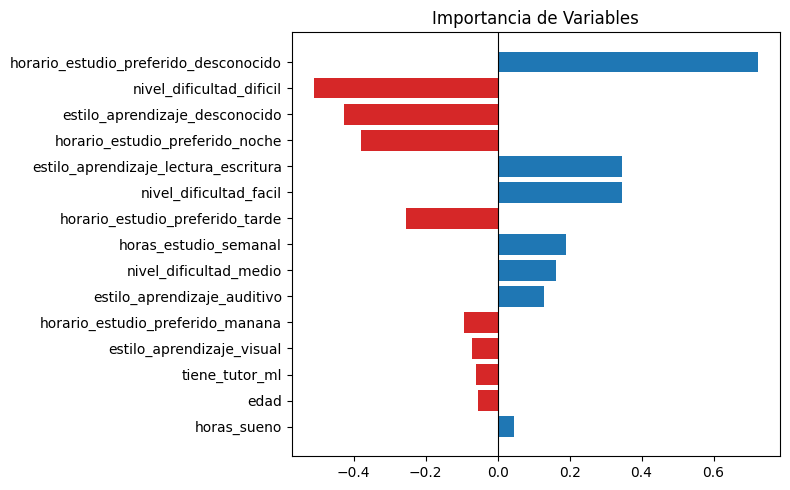

,variable,importancia
9,horario_estudio_preferido_desconocido,0.723084
6,nivel_dificultad_dificil,-0.510542
14,estilo_aprendizaje_desconocido,-0.427234
11,horario_estudio_preferido_noche,-0.379164
16,estilo_aprendizaje_lectura_escritura,0.345002
7,nivel_dificultad_facil,0.344354
12,horario_estudio_preferido_tarde,-0.254950
0,horas_estudio_semanal,0.190555
8,nivel_dificultad_medio,0.161969
13,estilo_aprendizaje_auditivo,0.128562


In [37]:
imp_log = sm.importancia_variables(
    modelo_log_final,
    X_clf.columns
)
imp_log

##### Tree

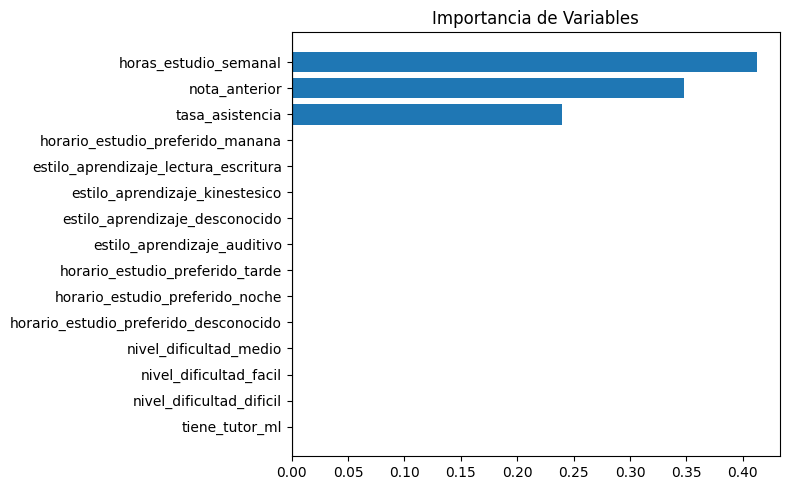

,variable,importancia
0,horas_estudio_semanal,0.412394
1,nota_anterior,0.348213
2,tasa_asistencia,0.239393
10,horario_estudio_preferido_manana,0.000000
16,estilo_aprendizaje_lectura_escritura,0.000000
15,estilo_aprendizaje_kinestesico,0.000000
14,estilo_aprendizaje_desconocido,0.000000
13,estilo_aprendizaje_auditivo,0.000000
12,horario_estudio_preferido_tarde,0.000000
11,horario_estudio_preferido_noche,0.000000


In [36]:
imp_tree = sm.importancia_variables(
    modelo_tree_final,
    X_clf.columns
)
imp_tree

Comparación de importancia de variables

Se comparan las variables relevantes identificadas por Logistic Regression y Decision Tree.

 Logistic Regression

El modelo distribuye la importancia entre múltiples variables, destacando:

- horario_estudio_preferido_desconocido
- nivel_dificultad_dificil
- nivel_dificultad_facil
- horas_estudio_semanal

 Decision Tree

El árbol simplifica significativamente la decisión y basa prácticamente toda la clasificación en:

1. horas_estudio_semanal
2. nota_anterior
3. tasa_asistencia

El resto de variables no son utilizadas por el modelo.

 Conclusión

Las tres variables identificadas por el árbol coinciden con los hallazgos obtenidos durante el EDA y el AB Testing.

Esto aporta consistencia al análisis completo y sugiere que:

- Las horas de estudio.
- El rendimiento previo.
- La asistencia.

son los factores con mayor capacidad predictiva para determinar si un estudiante aprobará o suspenderá.

### 15. Simulación

##### describe

In [41]:
X_train_clf.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
horas_estudio_semanal,800.0,0.00,1.00,-1.85,-0.72,-0.02,0.67,3.05
nota_anterior,800.0,0.00,1.00,-2.70,-0.71,0.01,0.71,2.02
tasa_asistencia,800.0,-0.00,1.00,-2.98,-0.69,0.06,0.78,1.43
horas_sueno,800.0,-0.00,1.00,-2.28,-0.65,0.00,0.60,2.27
edad,800.0,-0.00,1.00,-1.60,-0.73,0.14,0.72,1.59
tiene_tutor_ml,800.0,0.40,0.49,0.00,0.00,0.00,1.00,1.00
nivel_dificultad_dificil,800.0,0.18,0.38,0.00,0.00,0.00,0.00,1.00
nivel_dificultad_facil,800.0,0.31,0.46,0.00,0.00,0.00,1.00,1.00
nivel_dificultad_medio,800.0,0.51,0.50,0.00,0.00,1.00,1.00,1.00
horario_estudio_preferido_desconocido,800.0,0.10,0.30,0.00,0.00,0.00,0.00,1.00


`horas_estudio_semanal`

In [42]:
sim_horas = sm.simular_variable(
    modelo_tree_final,
    X_clf,
    columna='horas_estudio_semanal',
    valores=[-2,-1,0,1,2,3]
)

sim_horas

,horas_estudio_semanal,probabilidad
0,-2,0.8505
1,-1,0.8505
2,0,0.8505
3,1,0.8505
4,2,0.8505
5,3,0.8505


`nota_anterior`

In [43]:
sim_nota = sm.simular_variable(
    modelo_tree_final,
    X_clf,
    columna='nota_anterior',
    valores=[-2,-1,0,1,2]
)

sim_nota

,nota_anterior,probabilidad
0,-2,0.8829
1,-1,0.8829
2,0,0.8829
3,1,0.8829
4,2,0.8829


`tasa_asistencia`

In [44]:
sim_asistencia = sm.simular_variable(
    modelo_tree_final,
    X_clf,
    columna='tasa_asistencia',
    valores=[-2,-1,0,1]
)

sim_asistencia

,tasa_asistencia,probabilidad
0,-2,0.955
1,-1,0.955
2,0,0.955
3,1,0.955


Conclusiones de la simulación

Las simulaciones realizadas sobre el árbol optimizado mantienen una probabilidad prácticamente constante.

 Interpretación

El comportamiento es coherente con la naturaleza de los árboles de decisión.

A diferencia de los modelos lineales, los árboles no responden de forma gradual ante pequeños cambios en una variable, sino que toman decisiones mediante reglas y puntos de corte.

Por ello, distintas simulaciones pueden recorrer exactamente la misma rama del árbol y producir la misma probabilidad final.

 Conclusión

Las simulaciones no reflejan una relación continua entre variables y resultado, sino la estructura de decisiones aprendida por el árbol.

### Simulación de escenarios


Se realizan simulaciones modificando individualmente las variables más importantes identificadas por los modelos de clasificación:

- horas_estudio_semanal
- nota_anterior
- tasa_asistencia

El objetivo es observar cómo varía la probabilidad estimada de aprobar manteniendo constantes el resto de variables.

 Interpretación

Las simulaciones permiten transformar los resultados técnicos del modelo en conclusiones fácilmente interpretables desde el punto de vista académico y de negocio.

La variación de la probabilidad de aprobado ayuda a identificar qué variables tienen una mayor capacidad de influencia sobre el resultado final.

### Guardar Modelo 

#### guardar_modelo()

In [45]:
sm.guardar_modelo(
    modelo_log_final,
    '../data/processed/logistic_clasificacion.pkl'
)

Modelo guardado en: ../data/processed/logistic_clasificacion.pkl


In [46]:
sm.guardar_modelo(
    modelo_tree_final,
    '../data/processed/tree_clasificacion.pkl'
)

Modelo guardado en: ../data/processed/tree_clasificacion.pkl


### Modelo recomendado

Para predicción se recomienda Logistic Regression por su estabilidad y simplicidad.

### Modelo explicativo

Decision Tree permite interpretar fácilmente las reglas que determinan el aprobado o suspenso y confirma los hallazgos obtenidos durante el EDA y el AB Testing.